# Monetization Estimation

Revenue projections built on top of the retention/DAU simulation.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
from pathlib import Path

if Path.cwd().name == 'notebooks':
    os.chdir(Path.cwd().parent)

from aco_model.models import MonetizationParams, RetentionCurve
from aco_model.retention import load_installs, retention_vector, simulate
from aco_model.monetization import estimate_revenue
from aco_model.config import load_config
from aco_model.state import load_state, save_state, DEFAULT_STATE_PATH

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

# Try loading from shared state (written by notebook 01), fall back to config
cfg = load_config()
state = load_state()

if state is not None:
    # Build a SimResult-like object from state DAU
    # Re-simulate using the state's retention anchors for full cohort data
    installs = load_installs(cfg.installs_path)
    curve = RetentionCurve(anchors=state.retention_anchors)
    sim = simulate(installs, curve, state.sim_days)
    monetization = state.monetization
    print(f'=== Loaded from shared state ({DEFAULT_STATE_PATH}) ===')
    print(f'  Updated: {state.updated_at}')
    print(f'  Retention anchors: {state.retention_anchors}')
else:
    installs = load_installs(cfg.installs_path)
    sim = simulate(installs, cfg.retention, cfg.sim_days)
    monetization = cfg.monetization
    print(f'=== No state file found — using config.yaml defaults ===')

print(f'  Sim days: {sim.sim_days}')
print(f'  DAU range: {sim.dau.min():,} – {sim.dau.max():,}')
print(f'  Monetization: {monetization.pct_payers:.1%} payers, ${monetization.arppu:.2f} ARPPU')
print()
print('Tip: Run notebook 01 sliders to update the shared state, then re-run this cell.')

=== Loaded from shared state (output/state.json) ===
  Updated: 2026-03-24T15:28:13
  Retention anchors: [(0, 100.0), (1, 44.0), (7, 20.0), (30, 7.0), (90, 1.0000000000000002), (180, 0.0)]
  Sim days: 90
  DAU range: 15,182 – 56,191
  Monetization: 3.0% payers, $1.50 ARPPU

Tip: Run notebook 01 sliders to update the shared state, then re-run this cell.


## 1. Revenue Estimation

In [2]:
payers_slider = widgets.FloatSlider(value=monetization.pct_payers * 100, min=0.5, max=15.0, step=0.5,
                                     description='Payers %:')
arppu_slider = widgets.FloatSlider(value=monetization.arppu, min=0.25, max=50.0, step=0.25,
                                    description='ARPPU $:')

# Get current retention anchors for state saving
_current_anchors = state.retention_anchors if state else cfg.retention.anchors

def plot_revenue(payers_pct, arppu):
    params = MonetizationParams(pct_payers=payers_pct / 100.0, arppu=arppu)
    rev = estimate_revenue(sim, params)
    df = rev.to_dataframe()

    # Save state with updated monetization params
    save_state(sim, _current_anchors, monetization=params)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Daily revenue
    axes[0].fill_between(df['day'], df['daily_revenue_usd'], alpha=0.3, color='#4CAF50')
    axes[0].plot(df['day'], df['daily_revenue_usd'], linewidth=2, color='#4CAF50')
    axes[0].set_xlabel('Day')
    axes[0].set_ylabel('Daily Revenue (USD)')
    axes[0].set_title('Daily Revenue')

    # Cumulative revenue
    axes[1].plot(df['day'], df['cumulative_revenue_usd'], linewidth=2, color='#FF5722')
    axes[1].set_xlabel('Day')
    axes[1].set_ylabel('Cumulative Revenue (USD)')
    axes[1].set_title('Cumulative Revenue')

    # ARPDAU
    axes[2].plot(df['day'], df['arpdau_usd'], linewidth=2, color='#9C27B0')
    axes[2].set_xlabel('Day')
    axes[2].set_ylabel('ARPDAU (USD)')
    axes[2].set_title('ARPDAU')

    plt.tight_layout()
    plt.show()

    print(f'ARPDAU: ${params.pct_payers * params.arppu:,.4f}')
    print(f'Avg Lifetime Rev per Payer: ${rev.avg_lifetime_revenue_per_payer:,.2f}')
    print(f'Total Payers: {rev.total_payers:,}')
    print(f'Total Revenue: ${rev.total_revenue:,.2f}')
    print(f'Avg Daily Revenue: ${rev.total_revenue / sim.sim_days:,.2f}')
    print(f'Peak Daily Revenue: ${rev.daily_revenue.max():,.2f}')
    print(f'Avg Revenue per Cohort: ${rev.avg_revenue_per_cohort:,.2f}')

out_rev = widgets.interactive_output(plot_revenue, {
    'payers_pct': payers_slider, 'arppu': arppu_slider
})
display(widgets.VBox([
    widgets.HBox([payers_slider, arppu_slider]),
    out_rev
]))

## 2. Revenue Sensitivity

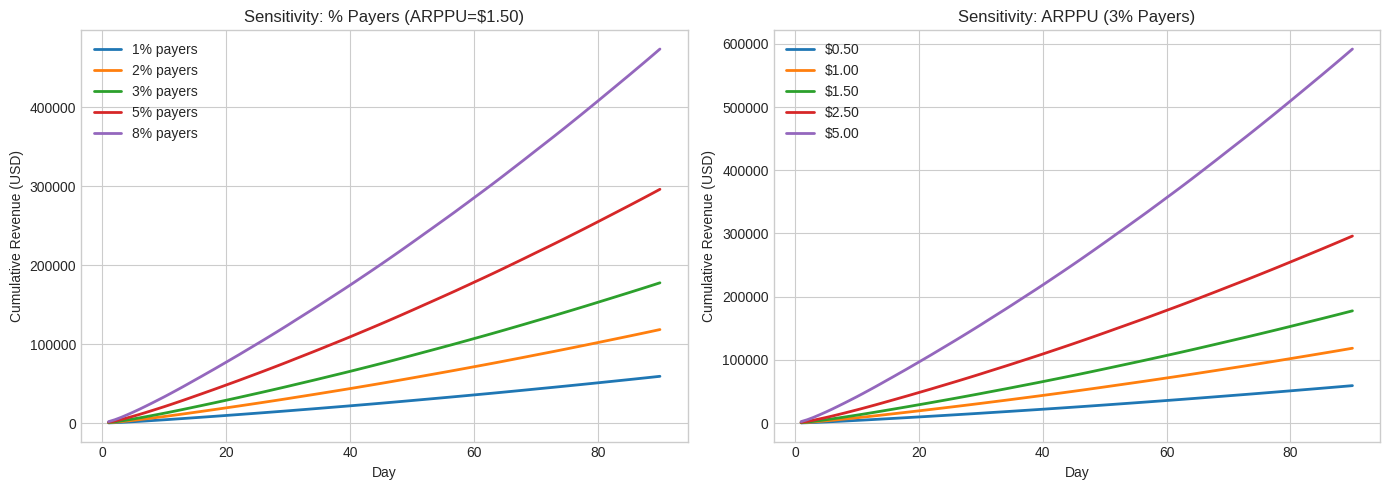

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Sensitivity to % payers
for pct in [1, 2, 3, 5, 8]:
    rev = estimate_revenue(sim, MonetizationParams(pct_payers=pct/100, arppu=1.50))
    ax1.plot(np.arange(1, sim.sim_days + 1), rev.cumulative_revenue,
             linewidth=2, label=f'{pct}% payers')
ax1.set_xlabel('Day')
ax1.set_ylabel('Cumulative Revenue (USD)')
ax1.set_title('Sensitivity: % Payers (ARPPU=$1.50)')
ax1.legend()

# Sensitivity to ARPPU
for arppu in [0.50, 1.00, 1.50, 2.50, 5.00]:
    rev = estimate_revenue(sim, MonetizationParams(pct_payers=0.03, arppu=arppu))
    ax2.plot(np.arange(1, sim.sim_days + 1), rev.cumulative_revenue,
             linewidth=2, label=f'${arppu:.2f}')
ax2.set_xlabel('Day')
ax2.set_ylabel('Cumulative Revenue (USD)')
ax2.set_title('Sensitivity: ARPPU (3% Payers)')
ax2.legend()

plt.tight_layout()
plt.show()

## 3. Revenue per Install Cohort

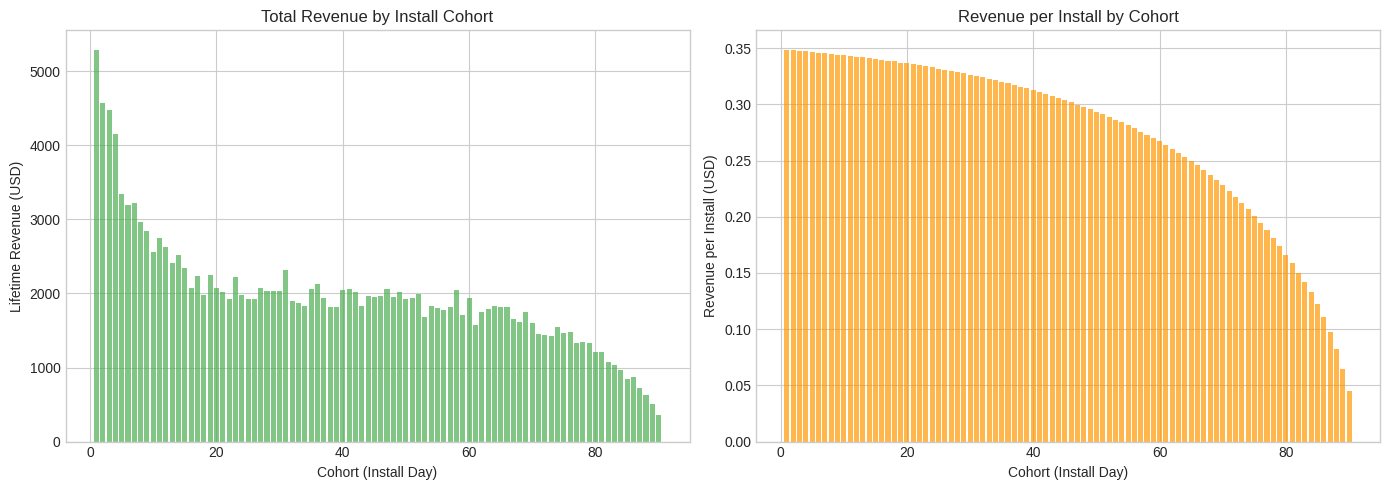

Avg Lifetime Revenue per Cohort: $1,972.97
Avg Revenue per Install: $0.2747
Best Cohort: Day 1 ($5,289.78)
Note: Earlier cohorts earn more because they have more retained days within the sim window.


In [4]:
rev = estimate_revenue(sim, monetization)
cdf = rev.cohort_revenue_dataframe()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Lifetime revenue per cohort
ax1.bar(cdf['cohort_day'], cdf['lifetime_revenue_usd'], alpha=0.7, color='#4CAF50')
ax1.set_xlabel('Cohort (Install Day)')
ax1.set_ylabel('Lifetime Revenue (USD)')
ax1.set_title('Total Revenue by Install Cohort')

# Revenue per install
ax2.bar(cdf['cohort_day'], cdf['revenue_per_install_usd'], alpha=0.7, color='#FF9800')
ax2.set_xlabel('Cohort (Install Day)')
ax2.set_ylabel('Revenue per Install (USD)')
ax2.set_title('Revenue per Install by Cohort')

plt.tight_layout()
plt.show()

print(f'Avg Lifetime Revenue per Cohort: ${rev.avg_revenue_per_cohort:,.2f}')
print(f'Avg Revenue per Install: ${cdf["revenue_per_install_usd"].mean():,.4f}')
print(f'Best Cohort: Day {cdf.loc[cdf["lifetime_revenue_usd"].idxmax(), "cohort_day"]} (${cdf["lifetime_revenue_usd"].max():,.2f})')
print(f'Note: Earlier cohorts earn more because they have more retained days within the sim window.')

## 4. Combined DAU + Revenue View

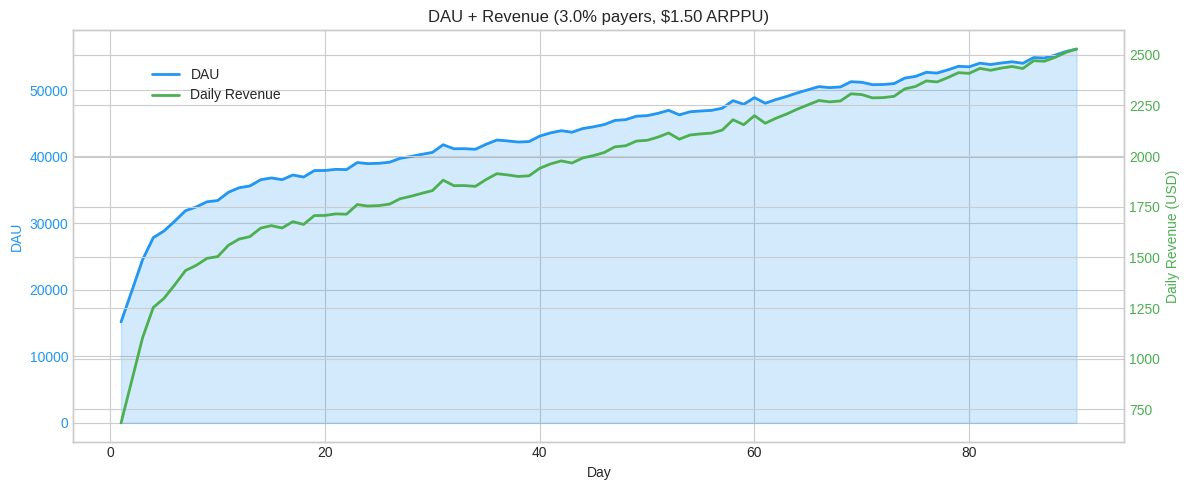

In [5]:
rev = estimate_revenue(sim, monetization)
days = np.arange(1, sim.sim_days + 1)

fig, ax1 = plt.subplots(figsize=(12, 5))

# DAU on left axis
ax1.fill_between(days, sim.dau, alpha=0.2, color='#2196F3')
ax1.plot(days, sim.dau, linewidth=2, color='#2196F3', label='DAU')
ax1.set_xlabel('Day')
ax1.set_ylabel('DAU', color='#2196F3')
ax1.tick_params(axis='y', labelcolor='#2196F3')

# Revenue on right axis
ax2 = ax1.twinx()
ax2.plot(days, rev.daily_revenue, linewidth=2, color='#4CAF50', label='Daily Revenue')
ax2.set_ylabel('Daily Revenue (USD)', color='#4CAF50')
ax2.tick_params(axis='y', labelcolor='#4CAF50')

ax1.set_title(f'DAU + Revenue ({monetization.pct_payers:.1%} payers, ${monetization.arppu:.2f} ARPPU)')
fig.legend(loc='upper left', bbox_to_anchor=(0.12, 0.88))
plt.tight_layout()
plt.show()